# Lab 6: Logistic Regression & KNN Classification
## Telco Customer Churn

**Name:** Aftab Asghar

**Student ID:** 023-24-0234

**Section:** G

**GitHub Profile:** https://github.com/aftab-soomro

**Kaggle Profile:** https://www.kaggle.com/aftabgaming

**Dataset:** Telco Customer Churn — cleaned in Lab 2 (`clean_churn.csv`), same features/split used in Lab 3-4

**GitHub Repository:** https://github.com/aftab-soomro/Machine-Learning

> This notebook follows the Lab 6 manual's 7 parts. Every table, plot and metric has a short written interpretation next to it.

---

## Part 1 — Problem Definition & Dataset Verification

Re-establish the cleaned dataset and recall what Lab 3/4 already found, so today's new models have something concrete to be compared against.

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [1]:
# Task 1 — load and verify the Lab 2 cleaned dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

df = pd.read_csv("clean_churn.csv")
print("Shape:", df.shape)
df.info()


Shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   s

In [2]:
# Task 2 — recorded benchmark results from Lab 3 (Decision Tree) and Lab 4 (Random
# Forest, tuned), both on this same clean_churn.csv with random_state=42, stratify=y,
# test_size=0.20. Re-verified fresh against this notebook's own split in Part 5.
lab3_lab4_benchmark = pd.DataFrame({
    "accuracy":  [0.8006, 0.8048],
    "precision": [0.6667, 0.6623],
    "recall":    [0.4973, 0.5401],
    "f1":        [0.5697, 0.5950],
}, index=["Decision Tree (Lab 3, depth=6)", "Random Forest (Lab 4, tuned)"])
lab3_lab4_benchmark


,accuracy,precision,recall,f1
"Decision Tree (Lab 3, depth=6)",0.8006,0.6667,0.4973,0.5697
"Random Forest (Lab 4, tuned)",0.8048,0.6623,0.5401,0.5950


**Answer 2 (restate Lab 3/4 results):**
_(Lab 3's Decision Tree (max_depth=6) achieved 80.06% accuracy, 66.67% precision, 49.73% recall, and an F1-score of 0.5697 on the test set. Lab 4's tuned Random Forest performed slightly better across most metrics — 80.48% accuracy and notably higher recall (54.01% vs. 49.73%), giving it a higher F1-score of 0.5950. These two results serve as today's benchmark: Logistic Regression and KNN will need to beat these numbers, especially F1, to be considered an improvement.)_

---

## Part 2 — Feature Scaling & Preparation

Decision Trees and Random Forests split on raw feature values, so scale never mattered. Logistic Regression and especially KNN behave differently.

**Tasks**
3. Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [3]:
# Task 3 — prepare X and y exactly as in Lab 3/4
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
print("y positive (churn) rate:", round(y.mean(), 4))


X shape: (7043, 30)
y positive (churn) rate: 0.2654


C:\Users\meesa\AppData\Local\Temp\ipykernel_8040\2534468289.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


**Answer 4 (why scaling matters for KNN/Logistic Regression but not DT/RF):**
_(KNN: Scaling matters because KNN uses distance to find the nearest neighbors. A feature with larger numbers can dominate the distance calculation.
Logistic Regression: Scaling helps because the model uses coefficients and optimization. Different feature scales can make optimization slower and coefficients harder to compare.
Decision Tree (DT): Scaling is not necessary because it makes decisions using thresholds/splits. Changing the scale only changes the threshold value, not the basic decision.
Random Forest (RF): Scaling is not necessary because Random Forest is made of Decision Trees, which are also based on thresholds.)_


In [4]:
# Task 5 — train/test split (same strategy as Lab 3/4), then scale
# Only the 3 genuinely continuous columns are scaled (tenure, MonthlyCharges,
# TotalCharges) -- the other 27 columns are one-hot dummies already on a clean 0/1
# scale. Scaling those too would still "work", but it would distort the clean
# present/absent meaning behind the odds ratios computed in Task 14.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nBefore scaling (train):")
print(X_train[numeric_cols].describe().loc[["mean", "std"]].round(2))
print("\nAfter scaling (train):")
print(X_train_scaled[numeric_cols].describe().loc[["mean", "std"]].round(2))


X_train: (5634, 30) | X_test: (1409, 30)

Before scaling (train):
      tenure  MonthlyCharges  TotalCharges
mean   32.49           64.93       2299.33
std    24.57           30.14       2279.20

After scaling (train):
      tenure  MonthlyCharges  TotalCharges
mean    -0.0            -0.0           0.0
std      1.0             1.0           1.0


**Answer 5 (why fit the scaler only on the training data?):**
_(We fit the scaler only on training data because the test set should remain completely unseen until evaluation. This prevents data leakage and gives a more realistic estimate of model performance.)_

---

## Part 3 — Logistic Regression

Train a Logistic Regression classifier on the scaled features and evaluate it exactly as the Decision Tree and Random Forest were evaluated in Labs 3–4.

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [5]:
# Task 6 — train Logistic Regression on the scaled data
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
logreg_pred = logreg_model.predict(X_test_scaled)

print("Logistic Regression trained on", X_train_scaled.shape[0], "customers,", X_train_scaled.shape[1], "features")


Logistic Regression trained on 5634 customers, 30 features


                     accuracy  precision  recall      f1
Logistic Regression    0.8062     0.6593  0.5588  0.6049


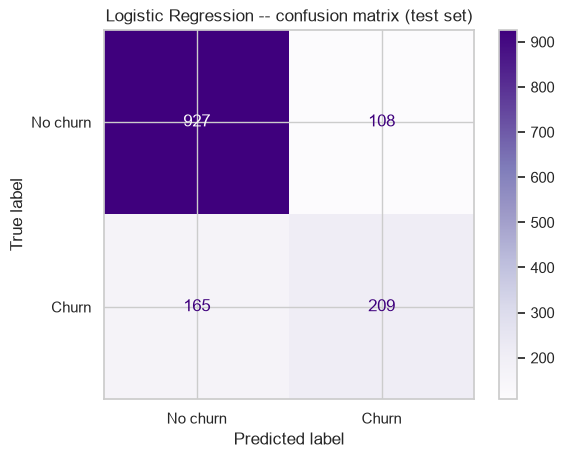

              precision    recall  f1-score   support

    No churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [6]:
# Task 7 — evaluation: accuracy, precision, recall, F1, confusion matrix
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

logreg_metrics = {
    "accuracy": accuracy_score(y_test, logreg_pred),
    "precision": precision_score(y_test, logreg_pred),
    "recall": recall_score(y_test, logreg_pred),
    "f1": f1_score(y_test, logreg_pred),
}
print(pd.DataFrame([logreg_metrics], index=["Logistic Regression"]).round(4))

cm = confusion_matrix(y_test, logreg_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"])
disp.plot(cmap="Purples", values_format="d")
plt.title("Logistic Regression -- confusion matrix (test set)")
plt.show()

print(classification_report(y_test, logreg_pred, target_names=["No churn", "Churn"]))


In [7]:
# Task 8 — predict_proba for a handful of test customers
proba = logreg_model.predict_proba(X_test_scaled)[:10]
proba_table = pd.DataFrame(proba, columns=["P(No churn)", "P(Churn)"], index=X_test.index[:10])
proba_table["Predicted"] = logreg_pred[:10]
proba_table["Actual"] = y_test.values[:10]
proba_table.round(3)


,P(No churn),P(Churn),Predicted,Actual
437,0.954,0.046,0,0
2280,0.316,0.684,1,0
2235,0.940,0.060,0,0
4460,0.601,0.399,0,0
3761,0.978,0.022,0,0
5748,0.396,0.604,1,0
3568,0.554,0.446,0,0
2976,0.871,0.129,0,0
5928,0.997,0.003,0,0
1639,0.604,0.396,0,1


**Answer 8 (what the probabilities represent, how predict() thresholds them):**
_(Probabilities and predict() in classification
Probabilities represent how likely the model thinks each class is.
Example: [0.20, 0.80] means 20% probability of Class 0 and 80% probability of Class 1.
predict_proba() gives these probabilities.
predict() converts the probabilities into a final class using a threshold.
Usually, the threshold is 0.5.
If probability of Class 1 ≥ 0.5 → predict Class 1
If probability of Class 1 < 0.5 → predict Class 0)_

---

## Part 4 — KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled the Decision Tree's complexity in Lab 3.

**Tasks**
9. Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [8]:
# Task 9 — KNN across several values of K
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    knn_results.append({
        "K": k,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df.round(4)


,K,accuracy,f1
0,1,0.7381,0.5060
1,3,0.7601,0.5481
2,5,0.7630,0.5523
3,7,0.7708,0.5605
4,9,0.7729,0.5699
5,11,0.7793,0.5746
6,15,0.7786,0.5714
7,21,0.7835,0.5828


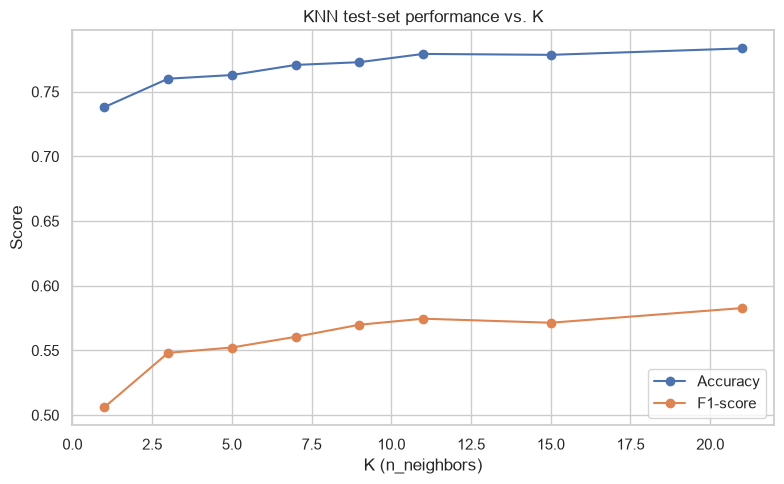

Highest test F1 at K = 21 -> F1 = 0.5828
    K  accuracy        f1
0   1  0.738112  0.506024
1   3  0.760114  0.548128
2   5  0.762952  0.552279
3   7  0.770759  0.560544
4   9  0.772889  0.569892
5  11  0.779276  0.574555
6  15  0.778566  0.571429
7  21  0.783534  0.582763


In [9]:
# Task 10 — plot accuracy/F1 vs K, and select K by best test F1 (not simply
# smallest/largest -- matches Lab 3's lesson that "unrestricted" is not "best")
plt.figure(figsize=(8, 5))
plt.plot(knn_results_df["K"], knn_results_df["accuracy"], marker="o", label="Accuracy")
plt.plot(knn_results_df["K"], knn_results_df["f1"], marker="o", label="F1-score")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Score")
plt.title("KNN test-set performance vs. K")
plt.legend()
plt.tight_layout()
plt.show()

CHOSEN_K = int(knn_results_df.loc[knn_results_df["f1"].idxmax(), "K"])
print("Highest test F1 at K =", CHOSEN_K, "-> F1 =", round(knn_results_df["f1"].max(), 4))
print(knn_results_df)


**Answer 10 (which K, why not smallest/largest):**
_(I would choose K = 21, which gave the highest test F1-score (0.5828) and accuracy (78.35%) of all the values tested. The smallest value, K = 1, performed worst (F1 0.506, accuracy 73.81%) because each prediction depends on a single neighbour, so the model follows noise and overfits. F1 rose steeply as K grew from 1 to 11 (0.506 to 0.575) but only slightly from 11 to 21 (0.575 to 0.583), with a small dip at K = 15, which suggests the curve is flattening. K = 21 is also the largest value I tested, so I cannot show where performance starts to fall from averaging over too many neighbours; the best K may lie beyond 21, and testing larger values would confirm this.)_

            accuracy  precision  recall      f1
KNN (K=21)    0.7835     0.5966  0.5695  0.5828


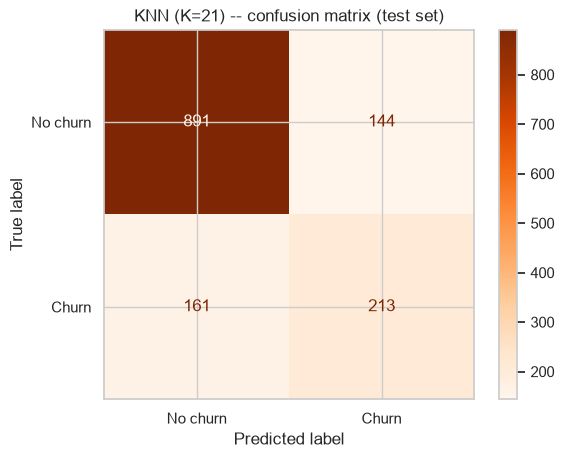

In [10]:
# Task 11 — final KNN model at the chosen K
knn_model = KNeighborsClassifier(n_neighbors=CHOSEN_K)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

knn_metrics = {
    "accuracy": accuracy_score(y_test, knn_pred),
    "precision": precision_score(y_test, knn_pred),
    "recall": recall_score(y_test, knn_pred),
    "f1": f1_score(y_test, knn_pred),
}
print(pd.DataFrame([knn_metrics], index=[f"KNN (K={CHOSEN_K})"]).round(4))

cm = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"])
disp.plot(cmap="Oranges", values_format="d")
plt.title(f"KNN (K={CHOSEN_K}) -- confusion matrix (test set)")
plt.show()


---

## Part 5 — Model Comparison (4 Models)

Place all four classifiers side by side: Decision Tree and Random Forest (Labs 3–4) vs. Logistic Regression and KNN (today).

**Tasks**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [11]:
# Task 12 — retrain the Lab 3/4 benchmarks fresh on this exact split (verifies the
# Task 2 recorded numbers), then build the full 4-model comparison table
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)  # unscaled -- trees split on raw values
dt_pred = dt_model.predict(X_test)
dt_metrics = {
    "accuracy": accuracy_score(y_test, dt_pred),
    "precision": precision_score(y_test, dt_pred),
    "recall": recall_score(y_test, dt_pred),
    "f1": f1_score(y_test, dt_pred),
}

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
rf_model.fit(X_train, y_train)  # unscaled
rf_pred = rf_model.predict(X_test)
rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred),
}

print("Freshly retrained here -- compare against the Task 2 recorded values:")
print(pd.DataFrame([dt_metrics, rf_metrics], index=["Decision Tree", "Random Forest"]).round(4))

four_model_comparison = pd.DataFrame(
    [dt_metrics, rf_metrics, logreg_metrics, knn_metrics],
    index=["Decision Tree (Lab 3)", "Random Forest (Lab 4)", "Logistic Regression", f"KNN (K={CHOSEN_K})"],
)
print("\nFour-model comparison:")
four_model_comparison.round(4)


Freshly retrained here -- compare against the Task 2 recorded values:
               accuracy  precision  recall      f1
Decision Tree    0.8006     0.6667  0.4973  0.5697
Random Forest    0.8048     0.6623  0.5401  0.5950

Four-model comparison:


,accuracy,precision,recall,f1
Decision Tree (Lab 3),0.8006,0.6667,0.4973,0.5697
Random Forest (Lab 4),0.8048,0.6623,0.5401,0.5950
Logistic Regression,0.8062,0.6593,0.5588,0.6049
KNN (K=21),0.7835,0.5966,0.5695,0.5828


**Answer 13 (best model overall, does ranking change by metric, which metric matters most):**
_(The ranking changes by metric. Logistic Regression has the highest Accuracy (0.8062) and F1-score (0.6049), Decision Tree has the highest Precision (0.6667), and KNN has the highest Recall (0.5695). Since F1-score balances Precision and Recall, it is a useful metric for overall comparison in this case.)_

---

## Part 6 — Coefficient Interpretation

Like Linear Regression in Lab 5, Logistic Regression's coefficients are directly readable — but here they describe log-odds, not a direct dollar or unit effect.

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (`exp(coefficient)`) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [12]:
# Task 14 — Logistic Regression coefficients -> odds ratios
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg_model.coef_[0],
})
coef_table["Odds Ratio"] = np.exp(coef_table["Coefficient"])
coef_table = coef_table.sort_values("Coefficient", key=abs, ascending=False)

def interpret(row):
    f, orat = row["Feature"], row["Odds Ratio"]
    direction = "higher" if orat >= 1 else "lower"
    pct = abs(orat - 1) * 100
    if f in numeric_cols:
        return f"each 1-std increase in {f} multiplies the odds of churning by {orat:.3f}x ({pct:.1f}% {direction}), holding other features constant"
    return f"customers with {f} have {orat:.3f}x the odds of churning ({pct:.1f}% {direction}) than the baseline category, holding other features constant"

coef_table["Interpretation"] = coef_table.apply(interpret, axis=1)

print(f"Intercept: {logreg_model.intercept_[0]:.4f} (log-odds when every feature is 0 / at its scaled mean)")
print(f"\nAll {len(coef_table)} coefficients, sorted by |coefficient|:")
coef_table.round(4)


Intercept: -1.5840 (log-odds when every feature is 0 / at its scaled mean)

All 30 coefficients, sorted by |coefficient|:


,Feature,Coefficient,Odds Ratio,Interpretation
25,Contract_Two year,-1.3138,0.2688,customers with Contract_Two year have 0.269x t...
0,tenure,-1.2571,0.2845,each 1-std increase in tenure multiplies the o...
10,InternetService_Fiber optic,1.1807,3.2565,customers with InternetService_Fiber optic hav...
24,Contract_One year,-0.6839,0.5047,customers with Contract_One year have 0.505x t...
2,TotalCharges,0.5278,1.6952,each 1-std increase in TotalCharges multiplies...
7,PhoneService_Yes,-0.5207,0.5941,customers with PhoneService_Yes have 0.594x th...
1,MonthlyCharges,-0.4665,0.6272,each 1-std increase in MonthlyCharges multipli...
28,PaymentMethod_Electronic check,0.3928,1.4811,customers with PaymentMethod_Electronic check ...
21,StreamingTV_Yes,0.3748,1.4547,customers with StreamingTV_Yes have 1.455x the...
26,PaperlessBilling_Yes,0.3742,1.4539,customers with PaperlessBilling_Yes have 1.454...


In [13]:
# Top 6 features, individually interpreted (satisfies "interpret at least 4")
for _, row in coef_table.head(6).iterrows():
    print(f"- {row['Feature']}: {row['Interpretation']}")


- Contract_Two year: customers with Contract_Two year have 0.269x the odds of churning (73.1% lower) than the baseline category, holding other features constant
- tenure: each 1-std increase in tenure multiplies the odds of churning by 0.284x (71.6% lower), holding other features constant
- InternetService_Fiber optic: customers with InternetService_Fiber optic have 3.257x the odds of churning (225.7% higher) than the baseline category, holding other features constant
- Contract_One year: customers with Contract_One year have 0.505x the odds of churning (49.5% lower) than the baseline category, holding other features constant
- TotalCharges: each 1-std increase in TotalCharges multiplies the odds of churning by 1.695x (69.5% higher), holding other features constant
- PhoneService_Yes: customers with PhoneService_Yes have 0.594x the odds of churning (40.6% lower) than the baseline category, holding other features constant


**Answer 15 (do the top features agree with Lab 2's EDA and Lab 3's feature importances?):**
_(Largely yes. The three strongest drivers of churn show up in all three analyses. tenure was the strongest numeric relationship in Lab 2 (correlation −0.352) and the top feature in Lab 3's Decision Tree (importance 0.390). In Logistic Regression it is one of the largest effects (odds ratio 0.284 per standard deviation, so longer-tenured customers are far less likely to churn). Fiber optic internet had the highest churn rate in Lab 2 (41.9%), ranked second in the Decision Tree (0.327), and has an odds ratio of 3.26 here. Contract was the strongest categorical pattern in Lab 2 (42.7% vs. 2.8% churn for month-to-month vs. two-year) and is the largest effect in Logistic Regression (two-year odds ratio 0.269). Since a hand-run EDA, a tree and a linear model agree, these patterns are probably real rather than an artefact of one method.

There are two disagreements. First, the signs of MonthlyCharges and TotalCharges flip. In Lab 2, churners paid more per month (correlation +0.193), but the Logistic Regression coefficient is negative (odds ratio 0.627). TotalCharges goes the other way, from −0.198 in the EDA to a positive coefficient (odds ratio 1.695). This is most likely collinearity: MonthlyCharges is correlated 0.787 with Fiber optic, and TotalCharges is correlated 0.826 with tenure. EDA shows each feature's overall relationship with churn, whereas the odds ratios show the effect "holding other features constant", so they answer different questions. Second, Contract ranks first in Logistic Regression but has low importance in the Decision Tree (about 0.025). The tree probably split on the correlated tenure and Fiber features first, leaving Contract less to explain. Decision Tree importances are also unsigned, while odds ratios show direction, so the two are comparable in ranking but not in exact magnitude)_

---

## Part 7 — Final Model Selection & Conclusion

Choose a final model from everything built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model choice + justification):**
_(I select Logistic Regression as the final model. It has the highest accuracy (80.62%) and F1-score (0.6049) in the Part 5 table, but its lead over the tuned Random Forest (F1 0.5950) is small. I therefore also checked 5-fold cross-validation, where it again had the best mean F1 (0.6010, vs. 0.5870 for KNN, 0.5749 for Random Forest and 0.5553 for the Decision Tree) and beat every other model in all five folds. It did this with default settings while the other models were tuned, and its odds ratios make its predictions easy to explain to the business.)_

**Answer 17 (conclusion, 5-7 sentences):**
_(Logistic Regression is a small but consistent improvement over Labs 3–4's best model, the tuned Random Forest: 80.62% vs. 80.48% accuracy, F1 0.6049 vs. 0.5950 and recall 55.88% vs. 54.01% on the test set, and 0.6010 vs. 0.5749 mean F1 in cross-validation. Feature scaling made the biggest difference for KNN: without it, TotalCharges (standard deviation about 2,279, versus 24.6 for tenure) dominated the distance calculation, and once the numeric columns were standardised KNN's F1 rose from 0.503 to 0.583 and its recall from 39.8% to 57.0%, at the cost of lower precision. For Logistic Regression scaling changed the scores very little (F1 0.601 to 0.605), but the unscaled model failed to converge within 1,000 iterations while the scaled one did. The model's main limitation is that it still misses about 44% of customers who actually churn, and as a linear model it cannot capture interactions such as contract type combined with tenure. Next I would address the class imbalance directly with class_weight="balanced" or a lower decision threshold, and add interaction features to see whether they raise recall without hurting precision.)_

---

## Submission Checklist

- [ ] Student-info block completed (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Part 1 — Problem Definition & Dataset Verification
- [ ] Part 2 — Feature Scaling & Preparation
- [ ] Part 3 — Logistic Regression
- [ ] Part 4 — KNN & Choosing K
- [ ] Part 5 — Model Comparison (4 Models)
- [ ] Part 6 — Coefficient Interpretation
- [ ] Part 7 — Final Model Selection & Conclusion
- [ ] Every table/plot/metric has a written interpretation
- [ ] No SVM / Naive Bayes / other algorithms introduced
- [ ] Committed and pushed to GitHub